In [1]:
# Cell 1: Mount Drive and check GPU
from google.colab import drive
import torch

drive.mount('/content/drive')

print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Check if dataset already exists
import os
if os.path.exists('/content/data_npy'):
    print("\n⚠️ Dataset already extracted!")
else:
    print("\n✓ Ready to extract dataset")


Mounted at /content/drive
GPU Available: True
GPU: Tesla T4
GPU Memory: 15.64 GB

✓ Ready to extract dataset


In [2]:
# Cell 2: Extract dataset from Drive (IDEMPOTENT - checks if already extracted)
import os
from pathlib import Path

# Check if already extracted
if Path('/content/data_npy').exists() and Path('/content/train.csv').exists():
    print("✓ Dataset already extracted locally")
    print("  - data_npy folder exists")
    print("  - CSV files exist")
    print("✓ Skipping extraction")
else:
    print("Dataset not found locally, extracting...")

    # Install 7z
    !apt-get install -y p7zip-full > /dev/null 2>&1

    # Extract
    print("Extracting dataset from Drive (5-10 minutes)...")
    !7z x "/content/drive/MyDrive/Colab Notebooks/symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0.7z" -o/content/ > /dev/null

    print("✓ Dataset extracted")

# Verify
!ls -lh /content/*.csv | head -5
!ls -lh /content/data_npy/


Dataset not found locally, extracting...
Extracting dataset from Drive (5-10 minutes)...
✓ Dataset extracted
-rw-r--r-- 1 root root 7.4M Oct 16  2024 /content/symile_mimic_data.csv
-rw-r--r-- 1 root root 4.6M Oct 16  2024 /content/test.csv
-rw-r--r-- 1 root root 9.8M Oct 16  2024 /content/train.csv
-rw-r--r-- 1 root root 758K Oct 16  2024 /content/val.csv
-rw-r--r-- 1 root root 7.4M Oct 16  2024 /content/val_retrieval.csv
total 16K
drwx------ 2 root root 4.0K Mar 19 12:15 test
drwx------ 2 root root 4.0K Mar 19 12:18 train
drwx------ 2 root root 4.0K Mar 19 12:18 val
drwx------ 2 root root 4.0K Mar 19 12:20 val_retrieval


In [3]:
# Cell 3: Install dependencies
!pip install -q ultralytics grad-cam torchxrayvision opencv-python scikit-image tqdm pandas pillow pyyaml
print("✓ Dependencies installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 17.1 MB/s eta 0:00:00
✓ Dependencies installed


In [4]:
# Cell 4: Setup backup system with FIXED paths
from pathlib import Path
import json
import time
import shutil

# Create backup directory
BACKUP_DIR = Path("/content/drive/MyDrive/Colab Notebooks/chest_xray_research")
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

def backup_model_results(model_name, project_dir="/content/runs/detect/chest_xray_detection"):
    """Backup trained model to Google Drive."""
    model_dir = Path(project_dir) / model_name
    backup_model_dir = BACKUP_DIR / model_name
    backup_model_dir.mkdir(parents=True, exist_ok=True)

    if not model_dir.exists():
        print(f"⚠️  Source not found: {model_dir}")
        return False

    print(f"\nBacking up {model_name}...")
    files_to_backup = [
        'weights/best.pt',
        'weights/last.pt',
        'results.csv',
        'results.png',
        'args.yaml'
    ]

    backed_up_count = 0
    for file_path in files_to_backup:
        src = model_dir / file_path
        if src.exists():
            dst = backup_model_dir / file_path
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            backed_up_count += 1
            print(f"  ✓ {file_path}")

    # Verify backup has weight files
    best_pt = backup_model_dir / "weights" / "best.pt"
    if best_pt.exists():
        print(f"✓ Backed up to: {backup_model_dir}")
        return True
    else:
        print(f"⚠️  Backup verification failed - no best.pt found")
        return False

def save_training_state(completed_models):
    """Save training state."""
    state = {
        'completed_models': completed_models,
        'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
    }
    with open(BACKUP_DIR / 'training_state.json', 'w') as f:
        json.dump(state, f, indent=2)
    print(f"✓ State saved: {completed_models}")

def load_training_state():
    """Load training state."""
    state_file = BACKUP_DIR / 'training_state.json'
    if state_file.exists():
        with open(state_file, 'r') as f:
            return json.load(f)
    return {'completed_models': []}

print(f"✓ Backup system ready (FIXED paths)")
print(f"✓ Backup location: {BACKUP_DIR}")
print(f"✓ Training output location: /content/runs/detect/chest_xray_detection/")


✓ Backup system ready (FIXED paths)
✓ Backup location: /content/drive/MyDrive/Colab Notebooks/chest_xray_research
✓ Training output location: /content/runs/detect/chest_xray_detection/


In [ ]:
# Cell 5: Load dataset OR restore from Drive (IDEMPOTENT)
import pandas as pd
import numpy as np
from pathlib import Path

# Check if dataset already exists in Drive
DATASET_BACKUP = BACKUP_DIR / "dataset"
BBOX_BACKUP = BACKUP_DIR / "pseudo_bboxes"

if (DATASET_BACKUP / "train" / "images").exists() and (BBOX_BACKUP / "all_pseudo_bboxes_coco.json").exists():
    print("="*60)
    print("✓ DATASET FOUND IN DRIVE - RESTORING")
    print("="*60)
    print(f"Location: {DATASET_BACKUP}")
    print("\nThis will skip pseudo-bbox generation (already done)")
    print("Copying dataset from Drive to local...")

    import shutil

    # Copy dataset from Drive to local
    if Path("/content/dataset").exists():
        shutil.rmtree("/content/dataset")
    shutil.copytree(DATASET_BACKUP, "/content/dataset")
    shutil.copy(BACKUP_DIR / "dataset.yaml", "/content/dataset.yaml")

    print("✓ Dataset restored from Drive")
    print(f"  Train images: {len(list((Path('/content/dataset/train/images')).glob('*.jpg')))}")
    print(f"  Val images: {len(list((Path('/content/dataset/val/images')).glob('*.jpg')))}")
    print("\n✓ SKIP TO CELL 8 TO START TRAINING")

    SKIP_BBOX_GENERATION = True

else:
    print("="*60)
    print("Dataset not in Drive - will generate from scratch")
    print("="*60)

    # Define paths
    DATASET_DIR = Path("/content")
    DATA_NPY_DIR = DATASET_DIR / "data_npy"
    OUTPUT_DIR = Path("/content/pseudo_bboxes")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Pathology mapping
    PATHOLOGIES = {
        "Atelectasis": 0,
        "Cardiomegaly": 1,
        "Edema": 2,
        "Lung Opacity": 3,
        "Pleural Effusion": 4
    }

    # Load train CSV
    print("Loading train.csv...")
    train_csv = pd.read_csv(DATASET_DIR / "train.csv")
    print(f"✓ Train samples: {len(train_csv)}")

    # Load .npy data
    print("Loading training images from .npy...")
    train_images = np.load(DATA_NPY_DIR / "train" / "cxr_train.npy", mmap_mode='r')
    train_hadm_ids = np.load(DATA_NPY_DIR / "train" / "hadm_id_train.npy")
    print(f"✓ Loaded {len(train_images)} images")
    print(f"✓ Image shape: {train_images.shape}")

    # Create hadm_id to index mapping
    hadm_id_to_idx = {hadm_id: idx for idx, hadm_id in enumerate(train_hadm_ids)}

    # Filter for multi-label samples
    def count_positive_labels(row):
        return sum(1 for col in PATHOLOGIES.keys() if col in row.index and row[col] == 1.0)

    train_csv['n_positive_labels'] = train_csv.apply(count_positive_labels, axis=1)
    multi_label_df = train_csv[train_csv['n_positive_labels'] >= 2].copy()

    print(f"\n✓ Total samples: {len(train_csv)}")
    print(f"✓ Multi-label samples (2+ pathologies): {len(multi_label_df)}")
    print(f"✓ Ready to generate pseudo-bboxes")

    SKIP_BBOX_GENERATION = False


✓ DATASET FOUND IN DRIVE - RESTORING
Location: /content/drive/MyDrive/Colab Notebooks/chest_xray_research/dataset

This will skip pseudo-bbox generation (already done)
Copying dataset from Drive to local...
✓ Dataset restored from Drive
  Train images: 3740
  Val images: 935

✓ SKIP TO CELL 8 TO START TRAINING


In [ ]:
# Cell 6: Generate pseudo-bboxes (SKIP if already in Drive)

if SKIP_BBOX_GENERATION:
    print("="*60)
    print("✓ SKIPPING PSEUDO-BBOX GENERATION")
    print("="*60)
    print("Dataset already exists in Drive")
    print("Proceed to Cell 8 to train models")
else:
    print("="*60)
    print("GENERATING PSEUDO-BBOXES")
    print("="*60)

    import torch
    import torchxrayvision as xrv
    from pytorch_grad_cam import GradCAM
    import cv2
    import numpy as np
    from tqdm import tqdm
    from skimage import measure
    import warnings
    warnings.filterwarnings('ignore')

    # Set device
    device = torch.device('cuda')
    print(f"Using device: {device}")

    # Grad-CAM parameters
    HEATMAP_THRESHOLD = 0.5
    MIN_BOX_SIZE = 32
    MAX_BOX_RATIO = 0.8
    IOU_THRESHOLD = 0.5

    # Load CheXpert model
    print("Loading CheXpert model (DenseNet121)...")
    model = xrv.models.DenseNet(weights="densenet121-res224-all")
    model = model.to(device)
    model.eval()
    target_layers = [model.features.denseblock4.denselayer16.conv2]
    print(f"✓ Model loaded on GPU")

    def preprocess_image(img_array):
        """Preprocess image for model."""
        if len(img_array.shape) == 3 and img_array.shape[0] == 3:
            img_gray = img_array.mean(axis=0)
        else:
            img_gray = img_array

        img_resized = cv2.resize(img_gray, (224, 224))

        if img_resized.max() > 1.0:
            img_resized = img_resized / 255.0

        img_tensor = torch.from_numpy(img_resized).unsqueeze(0).unsqueeze(0).float()
        return img_tensor.to(device), (320, 320)

    def generate_gradcam_heatmap(img_tensor):
        """Generate Grad-CAM heatmap."""
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=img_tensor, targets=None)
        return grayscale_cam[0, :]

    def extract_bboxes_from_heatmap(heatmap, original_size):
        """Extract bounding boxes from heatmap."""
        h, w = original_size
        heatmap_resized = cv2.resize(heatmap, (w, h))

        binary_mask = (heatmap_resized > HEATMAP_THRESHOLD).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

        labels = measure.label(binary_mask)
        regions = measure.regionprops(labels)

        bboxes = []
        for region in regions:
            minr, minc, maxr, maxc = region.bbox
            box_w = maxc - minc
            box_h = maxr - minr

            if box_w < MIN_BOX_SIZE or box_h < MIN_BOX_SIZE:
                continue
            if box_w > w * MAX_BOX_RATIO or box_h > h * MAX_BOX_RATIO:
                continue

            bboxes.append([minc, minr, box_w, box_h])

        return bboxes

    def merge_overlapping_boxes(bboxes):
        """Merge overlapping bounding boxes."""
        if len(bboxes) == 0:
            return []

        boxes = np.array([[x, y, x + w, y + h] for x, y, w, h in bboxes])
        keep = []
        indices = list(range(len(boxes)))

        while len(indices) > 0:
            i = indices[0]
            keep.append(i)
            indices.pop(0)

            if len(indices) == 0:
                break

            box1 = boxes[i]
            remaining_boxes = boxes[indices]

            x1 = np.maximum(box1[0], remaining_boxes[:, 0])
            y1 = np.maximum(box1[1], remaining_boxes[:, 1])
            x2 = np.minimum(box1[2], remaining_boxes[:, 2])
            y2 = np.minimum(box1[3], remaining_boxes[:, 3])

            intersection = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)
            area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
            area2 = (remaining_boxes[:, 2] - remaining_boxes[:, 0]) * (remaining_boxes[:, 3] - remaining_boxes[:, 1])
            union = area1 + area2 - intersection
            iou = intersection / union

            indices = [indices[j] for j in range(len(indices)) if iou[j] < IOU_THRESHOLD]

        merged_boxes = []
        for i in keep:
            x1, y1, x2, y2 = boxes[i]
            merged_boxes.append([x1, y1, x2 - x1, y2 - y1])

        return merged_boxes

    # Process all multi-label samples
    print(f"\nProcessing {len(multi_label_df)} samples...")
    print(f"Estimated time: ~{len(multi_label_df) * 0.12 / 60:.1f} minutes on GPU\n")

    results = []
    failed_count = 0

    for idx, row in tqdm(multi_label_df.iterrows(), total=len(multi_label_df), desc="Generating bboxes"):
        try:
            hadm_id = row['hadm_id']
            if hadm_id not in hadm_id_to_idx:
                failed_count += 1
                continue

            img_idx = hadm_id_to_idx[hadm_id]
            img_array = train_images[img_idx]

            img_tensor, original_size = preprocess_image(img_array)

            annotations = []
            for pathology, class_id in PATHOLOGIES.items():
                if pathology in row.index and row[pathology] == 1.0:
                    heatmap = generate_gradcam_heatmap(img_tensor)
                    bboxes = extract_bboxes_from_heatmap(heatmap, original_size)
                    bboxes = merge_overlapping_boxes(bboxes)

                    for bbox in bboxes:
                        annotations.append({
                            'pathology': pathology,
                            'class_id': class_id,
                            'bbox': bbox
                        })

            results.append({
                'hadm_id': int(hadm_id),
                'image_size': original_size,
                'annotations': annotations
            })

        except Exception as e:
            failed_count += 1
            continue

    total_boxes = sum(len(r['annotations']) for r in results)
    print(f"\n✓ Processed {len(results)}/{len(multi_label_df)} samples")
    print(f"✗ Failed: {failed_count}")
    print(f"✓ Generated {total_boxes} pseudo bounding boxes")
    print(f"✓ Average {total_boxes/len(results):.2f} boxes per image")


✓ SKIPPING PSEUDO-BBOX GENERATION
Dataset already exists in Drive
Proceed to Cell 8 to train models


In [ ]:
# Cell 7: Save YOLO format and backup to Drive (IDEMPOTENT)
import json
from sklearn.model_selection import train_test_split
from PIL import Image
import yaml
import shutil
from pathlib import Path

# Check if dataset already exists in Drive
DATASET_BACKUP = BACKUP_DIR / "dataset"
BBOX_BACKUP = BACKUP_DIR / "pseudo_bboxes"

if (DATASET_BACKUP / "train" / "images").exists() and (BBOX_BACKUP / "all_pseudo_bboxes_coco.json").exists():
    print("="*60)
    print("✓ DATASET ALREADY EXISTS IN DRIVE")
    print("="*60)
    print(f"Location: {DATASET_BACKUP}")
    print("\nSkipping dataset creation and backup")
    print("Dataset is already backed up from a previous run")
    print("\n✓ Proceed to Cell 8 to train models")

else:
    print("="*60)
    print("CREATING DATASET AND BACKING UP TO DRIVE")
    print("="*60)

    # Recreate output directory
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Create COCO format
    coco_data = {
        'images': [],
        'annotations': [],
        'categories': [{'id': i, 'name': name, 'supercategory': 'pathology'}
                       for name, i in PATHOLOGIES.items()]
    }

    annotation_id = 0
    for image_id, result in enumerate(results):
        w, h = result['image_size']
        coco_data['images'].append({
            'id': image_id,
            'hadm_id': result['hadm_id'],
            'width': w,
            'height': h
        })

        for ann in result['annotations']:
            x, y, w, h = ann['bbox']
            coco_data['annotations'].append({
                'id': annotation_id,
                'image_id': image_id,
                'category_id': ann['class_id'],
                'bbox': [float(x), float(y), float(w), float(h)],
                'area': float(w * h),
                'iscrowd': 0
            })
            annotation_id += 1

    # Save COCO format
    with open(OUTPUT_DIR / "all_pseudo_bboxes_coco.json", 'w') as f:
        json.dump(coco_data, f)

    print(f"✓ COCO format saved: {len(coco_data['images'])} images, {len(coco_data['annotations'])} boxes")

    # Split train/val (80/20)
    train_results, val_results = train_test_split(results, test_size=0.2, random_state=42)
    print(f"✓ Split: {len(train_results)} train, {len(val_results)} val")

    # Create dataset directories
    DATASET_DIR = Path("/content/dataset")
    for split in ['train', 'val']:
        (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
        (DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

    # Save images and YOLO labels
    def save_split(split_results, split_name):
        print(f"\nSaving {split_name} split...")

        for result in tqdm(split_results, desc=f"{split_name} images"):
            hadm_id = result['hadm_id']
            img_idx = hadm_id_to_idx[hadm_id]
            img_array = train_images[img_idx]

            # Convert to PIL image
            img_array = np.transpose(img_array, (1, 2, 0))
            if img_array.max() <= 1.0:
                img_array = (img_array * 255).astype(np.uint8)
            else:
                img_array = img_array.astype(np.uint8)

            # Save image
            img = Image.fromarray(img_array)
            img.save(DATASET_DIR / split_name / 'images' / f"{hadm_id}.jpg", quality=95)

            # Save YOLO label
            w, h = result['image_size']
            with open(DATASET_DIR / split_name / 'labels' / f"{hadm_id}.txt", 'w') as f:
                for ann in result['annotations']:
                    x, y, box_w, box_h = ann['bbox']
                    # Convert to YOLO format (normalized center coordinates)
                    x_center = (x + box_w / 2) / w
                    y_center = (y + box_h / 2) / h
                    width = box_w / w
                    height = box_h / h
                    class_id = ann['class_id']
                    f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    save_split(train_results, 'train')
    save_split(val_results, 'val')

    # Create dataset.yaml
    dataset_config = {
        'path': '/content/dataset',
        'train': 'train/images',
        'val': 'val/images',
        'names': {i: name for name, i in PATHOLOGIES.items()},
        'nc': len(PATHOLOGIES)
    }

    with open('/content/dataset.yaml', 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)

    print(f"\n✓ Dataset ready for YOLO training")
    print(f"✓ Train: {len(train_results)} images")
    print(f"✓ Val: {len(val_results)} images")

    # BACKUP TO GOOGLE DRIVE
    print(f"\n{'='*60}")
    print("BACKING UP TO GOOGLE DRIVE")
    print(f"{'='*60}")

    # Backup pseudo-bboxes
    bbox_backup = BACKUP_DIR / "pseudo_bboxes"
    bbox_backup.mkdir(parents=True, exist_ok=True)
    shutil.copy(OUTPUT_DIR / "all_pseudo_bboxes_coco.json", bbox_backup / "all_pseudo_bboxes_coco.json")
    print(f"✓ Backed up COCO annotations")

    # Backup dataset (images + labels)
    print("Backing up dataset to Drive (5-10 minutes)...")
    dataset_backup = BACKUP_DIR / "dataset"
    if dataset_backup.exists():
        shutil.rmtree(dataset_backup)
    shutil.copytree(DATASET_DIR, dataset_backup)
    shutil.copy('/content/dataset.yaml', BACKUP_DIR / 'dataset.yaml')
    print(f"✓ Backed up dataset: {dataset_backup}")

    # Backup CSV files
    for csv_file in ['/content/train.csv', '/content/val.csv', '/content/test.csv']:
        if Path(csv_file).exists():
            shutil.copy(csv_file, BACKUP_DIR / Path(csv_file).name)
    print(f"✓ Backed up CSV files")

    print(f"\n{'='*60}")
    print("✓ BACKUP COMPLETE")
    print(f"{'='*60}")
    print(f"Location: {BACKUP_DIR}")
    print(f"\nBacked up (~5GB total):")
    print(f"  ✓ Dataset images (train/val JPGs)")
    print(f"  ✓ YOLO labels (txt files)")
    print(f"  ✓ COCO annotations (json)")
    print(f"  ✓ dataset.yaml config")
    print(f"  ✓ CSV files")
    print(f"\n✓ Ready to train models!")


✓ DATASET ALREADY EXISTS IN DRIVE
Location: /content/drive/MyDrive/Colab Notebooks/chest_xray_research/dataset

Skipping dataset creation and backup
Dataset is already backed up from a previous run

✓ Proceed to Cell 8 to train models


In [ ]:
# Cell 8: Train models with idempotent Drive checks (FIXED)
from ultralytics import YOLO
import time
import gc
import torch
from pathlib import Path

# Check Drive for already trained models
def check_model_in_drive(model_name):
    """
    Check if model is already trained and backed up in Drive.

    FIXED: Now verifies that backup actually contains weight files, not just folder.
    """
    backup_model_dir = BACKUP_DIR / model_name
    best_weights = backup_model_dir / "weights" / "best.pt"

    if not backup_model_dir.exists():
        return False

    # Verify backup has actual weight files
    if not best_weights.exists():
        print(f"⚠️  {model_name}: Backup folder exists but missing best.pt")
        return False

    # Check file size to ensure it's not empty
    if best_weights.stat().st_size < 1000:  # Less than 1KB is suspicious
        print(f"⚠️  {model_name}: best.pt file is too small ({best_weights.stat().st_size} bytes)")
        return False

    return True

# All 4 models to train (smallest and largest of each architecture)
all_models = [
    ('yolo26n.pt', 'yolo26n', 48),  # YOLO26 nano (smallest)
    ('yolo26x.pt', 'yolo26x', 12),  # YOLO26 xlarge (largest)
    ('rtdetr-l.pt', 'rtdetr_l', 16), # RT-DETR large
    ('rtdetr-x.pt', 'rtdetr_x', 8),  # RT-DETR xlarge
]

print("="*60)
print("CHECKING DRIVE FOR EXISTING MODELS")
print("="*60)
print(f"Drive location: {BACKUP_DIR}")
print()

# Check which models are already done
completed = []
for model_file, exp_name, batch_size in all_models:
    if check_model_in_drive(exp_name):
        print(f"  ✓ {exp_name}: Found in Drive (SKIP)")
        completed.append(exp_name)
    else:
        print(f"  ⏳ {exp_name}: Not found (TRAIN)")

print(f"\n✓ Found {len(completed)}/4 models in Drive")

# Find next model to train
next_model = None
for model_file, exp_name, batch_size in all_models:
    if exp_name not in completed:
        next_model = (model_file, exp_name, batch_size)
        break

if next_model is None:
    print("\n" + "="*60)
    print("🎉 ALL 4 MODELS COMPLETE!")
    print("="*60)
    print(f"All models backed up to: {BACKUP_DIR}")
    print(f"\nCompleted models:")
    for model_name in [m[1] for m in all_models]:
        backup_path = BACKUP_DIR / model_name / "weights" / "best.pt"
        size_mb = backup_path.stat().st_size / (1024*1024) if backup_path.exists() else 0
        print(f"  ✓ {model_name} ({size_mb:.1f} MB)")
else:
    model_file, exp_name, batch_size = next_model

    print("\n" + "="*60)
    print(f"TRAINING: {exp_name.upper()}")
    print("="*60)
    print(f"Batch size: {batch_size}")
    print(f"Already completed: {completed if completed else 'None'}")
    print(f"Remaining after this: {3 - len(completed)} models")
    print("="*60)

    # Clear memory
    gc.collect()
    torch.cuda.empty_cache()

    start_time = time.time()

    try:
        model = YOLO(model_file)

        results = model.train(
            data='/content/dataset.yaml',
            epochs=100,
            imgsz=640,
            batch=batch_size,
            patience=20,
            device=0,
            workers=4,
            project='chest_xray_detection',  # This creates /content/runs/detect/chest_xray_detection/
            name=exp_name,
            exist_ok=True,
            optimizer='AdamW',
            lr0=0.001,
            cache='disk',
            verbose=True
        )

        train_time = (time.time() - start_time) / 3600
        best_map = results.results_dict.get('metrics/mAP50(B)', 0)

        print(f"\n{'='*60}")
        print(f"✓ {exp_name.upper()} TRAINING COMPLETE!")
        print(f"{'='*60}")
        print(f"Time: {train_time:.2f} hours")
        print(f"Best mAP50: {best_map:.4f}")

        # BACKUP MODEL TO DRIVE
        print(f"\nBacking up {exp_name} to Drive...")
        backup_success = backup_model_results(exp_name)

        if backup_success:
            # Update completed list
            completed.append(exp_name)
            save_training_state(completed)

            print(f"\n{'='*60}")
            print(f"✓ PROGRESS: {len(completed)}/4 MODELS COMPLETE")
            print(f"{'='*60}")
            print(f"Completed: {completed}")

            remaining = [m[1] for m in all_models if m[1] not in completed]
            if remaining:
                print(f"Remaining: {remaining}")
                print(f"\n✓ Run Cell 8 again to train next model")
            else:
                print(f"\n🎉 ALL MODELS COMPLETE!")
        else:
            print(f"\n{'='*60}")
            print(f"⚠️  BACKUP FAILED FOR {exp_name.upper()}")
            print(f"{'='*60}")
            print(f"Training completed but backup verification failed.")
            print(f"Check Drive manually: {BACKUP_DIR / exp_name}")
            print(f"\nRun Cell 8 again to retry backup or continue to next model")

        # Clean up
        del model
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n{'='*60}")
        print(f"✗ {exp_name.upper()} FAILED")
        print(f"{'='*60}")
        print(f"Error: {str(e)}")
        print(f"\nThe model was NOT backed up.")
        print(f"Run Cell 8 again to retry training {exp_name}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CHECKING DRIVE FOR EXISTING MODELS
Drive location: /content/drive/MyDrive/Colab Notebooks/chest_xray_research

  ✓ yolo26n: Found in Drive (SKIP)
  ✓ yolo26x: Found in Drive (SKIP)
  ✓ rtdetr_l: Found in Drive (SKIP)
  ✓ rtdetr_x: Found in Drive (SKIP)

✓ Found 4/4 models in Drive

🎉 ALL 4 MODELS COMPLETE!
All models backed up to: /content/drive/MyDrive/Colab Notebooks/chest_xray_research

Completed models:
  ✓ yolo26n (5.1 MB)
  ✓ yolo26x (112.9 MB)
  ✓ rtdetr_l (63.2 MB)
  ✓ rtdetr_x (129.2 MB)


In [ ]:
# Cell 9: Restore validation dataset from Drive (IDEMPOTENT)
from pathlib import Path
import shutil

print("="*60)
print("PREPARING VALIDATION DATASET FOR EVALUATION")
print("="*60)

BACKUP_DIR = Path("/content/drive/MyDrive/Colab Notebooks/chest_xray_research")
LOCAL_DATASET = Path("/content/dataset")

# Check if dataset already restored locally
if LOCAL_DATASET.exists() and (LOCAL_DATASET / "val" / "images").exists():
    val_images = len(list((LOCAL_DATASET / "val" / "images").glob("*.jpg")))
    print(f"✓ Validation dataset already exists locally")
    print(f"  Val images: {val_images}")
    print("\n✓ Skip to Cell 10 for evaluation")
else:
    print("Restoring dataset from Drive...")

    # Copy dataset from Drive
    if LOCAL_DATASET.exists():
        shutil.rmtree(LOCAL_DATASET)

    shutil.copytree(BACKUP_DIR / "dataset", LOCAL_DATASET)
    shutil.copy(BACKUP_DIR / "dataset.yaml", "/content/dataset.yaml")

    train_images = len(list((LOCAL_DATASET / "train" / "images").glob("*.jpg")))
    val_images = len(list((LOCAL_DATASET / "val" / "images").glob("*.jpg")))

    print(f"\n✓ Dataset restored from Drive")
    print(f"  Train images: {train_images}")
    print(f"  Val images: {val_images}")
    print(f"\n✓ Ready for evaluation")

PREPARING VALIDATION DATASET FOR EVALUATION
✓ Validation dataset already exists locally
  Val images: 935

✓ Skip to Cell 10 for evaluation


In [ ]:
# Cell 10: Run evaluation on validation set (IDEMPOTENT)
from ultralytics import YOLO
import time
import json
from pathlib import Path

print("="*60)
print("EVALUATING ALL 4 MODELS ON VALIDATION SET")
print("="*60)

BACKUP_DIR = Path("/content/drive/MyDrive/Colab Notebooks/chest_xray_research")
RESULTS_FILE = BACKUP_DIR / "validation_results.json"

# Check if results already exist
if RESULTS_FILE.exists():
    print(f"\n⚠️  Results file already exists: {RESULTS_FILE}")
    print("Loading existing results...")
    with open(RESULTS_FILE, 'r') as f:
        existing_results = json.load(f)
    print(f"✓ Found results for: {list(existing_results.keys())}")
    print("\nTo re-run evaluation, delete the file or rename it.")
    print("Otherwise, skip to Cell 11 for analysis.")
else:
    # Models to evaluate
    models_to_test = [
        ('yolo26n', 'YOLO26 Nano'),
        ('yolo26x', 'YOLO26 XLarge'),
        ('rtdetr_l', 'RT-DETR Large'),
        ('rtdetr_x', 'RT-DETR XLarge'),
    ]

    all_results = {}

    for model_name, display_name in models_to_test:
        print(f"\n{'='*60}")
        print(f"Testing: {display_name}")
        print(f"{'='*60}")

        model_path = BACKUP_DIR / model_name / "weights" / "best.pt"

        if not model_path.exists():
            print(f"⚠️  Model not found: {model_path}")
            continue

        # Load model
        print(f"Loading model from: {model_path}")
        model = YOLO(str(model_path))

        # Run validation with metrics
        print(f"\nRunning validation on 935 images...")
        print("This calculates mAP, precision, recall with ground truth labels")

        start_time = time.time()

        # Use model.val() for proper metrics calculation
        val_results = model.val(
            data='/content/dataset.yaml',
            split='val',
            batch=16,
            imgsz=640,
            conf=0.001,  # Lower threshold to catch more detections
            iou=0.6,
            device=0,
            verbose=False,
            plots=False
        )

        inference_time = time.time() - start_time

        # Extract metrics
        results_dict = val_results.results_dict

        # Get detection statistics
        total_images = 935  # Val set size
        avg_latency = (inference_time / total_images) * 1000  # ms per image

        print(f"\n✓ Validation complete")
        print(f"  Total time: {inference_time:.2f}s")
        print(f"  Avg latency: {avg_latency:.2f}ms per image")
        print(f"  mAP50: {results_dict.get('metrics/mAP50(B)', 0):.4f}")
        print(f"  mAP50-95: {results_dict.get('metrics/mAP50-95(B)', 0):.4f}")
        print(f"  Precision: {results_dict.get('metrics/precision(B)', 0):.4f}")
        print(f"  Recall: {results_dict.get('metrics/recall(B)', 0):.4f}")

        # Store results
        all_results[model_name] = {
            'display_name': display_name,
            'total_images': total_images,
            'inference_time_seconds': inference_time,
            'avg_latency_ms': avg_latency,
            'mAP50': float(results_dict.get('metrics/mAP50(B)', 0)),
            'mAP50_95': float(results_dict.get('metrics/mAP50-95(B)', 0)),
            'precision': float(results_dict.get('metrics/precision(B)', 0)),
            'recall': float(results_dict.get('metrics/recall(B)', 0)),
        }

    # Save results to Drive
    print(f"\n{'='*60}")
    print("SAVING RESULTS TO DRIVE")
    print(f"{'='*60}")

    with open(RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=2)

    print(f"✓ Results saved to: {RESULTS_FILE}")
    print(f"\n✓ Proceed to Cell 11 for analysis")

EVALUATING ALL 4 MODELS ON VALIDATION SET

⚠️  Results file already exists: /content/drive/MyDrive/Colab Notebooks/chest_xray_research/validation_results.json
Loading existing results...
✓ Found results for: ['yolo26n', 'yolo26x', 'rtdetr_l', 'rtdetr_x']

To re-run evaluation, delete the file or rename it.
Otherwise, skip to Cell 11 for analysis.


RESULTS ANALYSIS

ACCURACY & LATENCY COMPARISON
         Model Latency (ms)  mAP50 mAP50-95 Precision Recall
   YOLO26 Nano        13.62 0.5182   0.5163    0.4752 0.9181
 YOLO26 XLarge        80.80 0.5449   0.5430    0.5035 0.9706
 RT-DETR Large        46.74 0.2753   0.1484    0.3092 0.4996
RT-DETR XLarge        73.22 0.1545   0.0662    0.1087 0.5301

✓ Saved to: /content/drive/MyDrive/Colab Notebooks/chest_xray_research/validation_comparison_table.csv
✓ Saved plot to: /content/drive/MyDrive/Colab Notebooks/chest_xray_research/validation_comparison_plot.png


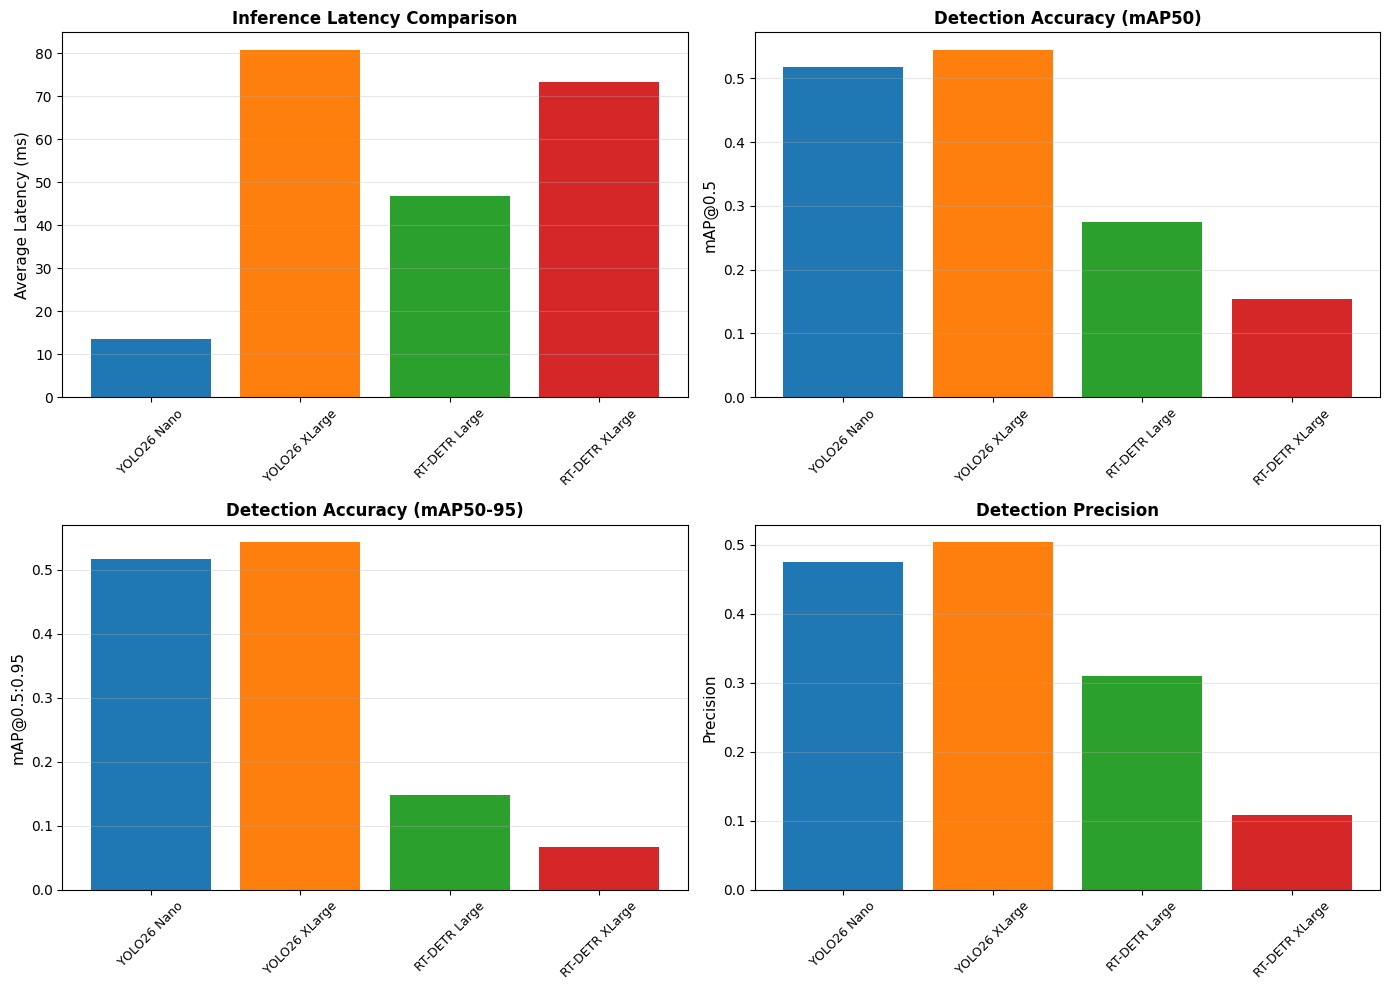


KEY FINDINGS

Latency:
  Fastest: YOLO26 Nano (13.62ms)
  Slowest: YOLO26 XLarge (80.80ms)
  Speedup: 5.93x

Accuracy (mAP50):
  Best: YOLO26 XLarge (0.5449)
  Worst: RT-DETR XLarge (0.1545)

Architecture Comparison:
  YOLO26 (CNN): 47.21ms avg latency, 0.5315 avg mAP50
  RT-DETR (Transformer): 59.98ms avg latency, 0.2149 avg mAP50
  → YOLO26 is 1.27x faster on average
  → YOLO26 is 147.3% more accurate on average

✓ Evaluation complete!

All results saved to: /content/drive/MyDrive/Colab Notebooks/chest_xray_research


In [ ]:
# Cell 11: Analyze and compare results
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("="*60)
print("RESULTS ANALYSIS")
print("="*60)

BACKUP_DIR = Path("/content/drive/MyDrive/Colab Notebooks/chest_xray_research")
RESULTS_FILE = BACKUP_DIR / "validation_results.json"

# Load results
with open(RESULTS_FILE, 'r') as f:
    results = json.load(f)

# Create comparison table
comparison_data = []
for model_name, data in results.items():
    comparison_data.append({
        'Model': data['display_name'],
        'Latency (ms)': f"{data['avg_latency_ms']:.2f}",
        'mAP50': f"{data['mAP50']:.4f}",
        'mAP50-95': f"{data['mAP50_95']:.4f}",
        'Precision': f"{data['precision']:.4f}",
        'Recall': f"{data['recall']:.4f}",
    })

df = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print("ACCURACY & LATENCY COMPARISON")
print("="*60)
print(df.to_string(index=False))

# Save comparison table
df.to_csv(BACKUP_DIR / "validation_comparison_table.csv", index=False)
print(f"\n✓ Saved to: {BACKUP_DIR / 'validation_comparison_table.csv'}")

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

models = [data['display_name'] for data in results.values()]
latencies = [data['avg_latency_ms'] for data in results.values()]
map50 = [data['mAP50'] for data in results.values()]
map50_95 = [data['mAP50_95'] for data in results.values()]
precision = [data['precision'] for data in results.values()]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Latency comparison
ax1.bar(models, latencies, color=colors)
ax1.set_ylabel('Average Latency (ms)', fontsize=11)
ax1.set_title('Inference Latency Comparison', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.grid(axis='y', alpha=0.3)

# mAP50 comparison
ax2.bar(models, map50, color=colors)
ax2.set_ylabel('mAP@0.5', fontsize=11)
ax2.set_title('Detection Accuracy (mAP50)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.grid(axis='y', alpha=0.3)

# mAP50-95 comparison
ax3.bar(models, map50_95, color=colors)
ax3.set_ylabel('mAP@0.5:0.95', fontsize=11)
ax3.set_title('Detection Accuracy (mAP50-95)', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=9)
ax3.grid(axis='y', alpha=0.3)

# Precision comparison
ax4.bar(models, precision, color=colors)
ax4.set_ylabel('Precision', fontsize=11)
ax4.set_title('Detection Precision', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=9)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BACKUP_DIR / 'validation_comparison_plot.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved plot to: {BACKUP_DIR / 'validation_comparison_plot.png'}")

plt.show()

# Key findings
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Find fastest and slowest
fastest = min(results.items(), key=lambda x: x[1]['avg_latency_ms'])
slowest = max(results.items(), key=lambda x: x[1]['avg_latency_ms'])

print(f"\nLatency:")
print(f"  Fastest: {fastest[1]['display_name']} ({fastest[1]['avg_latency_ms']:.2f}ms)")
print(f"  Slowest: {slowest[1]['display_name']} ({slowest[1]['avg_latency_ms']:.2f}ms)")
print(f"  Speedup: {slowest[1]['avg_latency_ms'] / fastest[1]['avg_latency_ms']:.2f}x")

# Find best accuracy
best_map50 = max(results.items(), key=lambda x: x[1]['mAP50'])
worst_map50 = min(results.items(), key=lambda x: x[1]['mAP50'])

print(f"\nAccuracy (mAP50):")
print(f"  Best: {best_map50[1]['display_name']} ({best_map50[1]['mAP50']:.4f})")
print(f"  Worst: {worst_map50[1]['display_name']} ({worst_map50[1]['mAP50']:.4f})")

# Architecture comparison
yolo_models = {k: v for k, v in results.items() if 'yolo' in k}
rtdetr_models = {k: v for k, v in results.items() if 'rtdetr' in k}

if yolo_models and rtdetr_models:
    yolo_avg_latency = sum(v['avg_latency_ms'] for v in yolo_models.values()) / len(yolo_models)
    rtdetr_avg_latency = sum(v['avg_latency_ms'] for v in rtdetr_models.values()) / len(rtdetr_models)

    yolo_avg_map = sum(v['mAP50'] for v in yolo_models.values()) / len(yolo_models)
    rtdetr_avg_map = sum(v['mAP50'] for v in rtdetr_models.values()) / len(rtdetr_models)

    print(f"\nArchitecture Comparison:")
    print(f"  YOLO26 (CNN): {yolo_avg_latency:.2f}ms avg latency, {yolo_avg_map:.4f} avg mAP50")
    print(f"  RT-DETR (Transformer): {rtdetr_avg_latency:.2f}ms avg latency, {rtdetr_avg_map:.4f} avg mAP50")

    if yolo_avg_latency < rtdetr_avg_latency:
        speedup = rtdetr_avg_latency / yolo_avg_latency
        print(f"  → YOLO26 is {speedup:.2f}x faster on average")

    if yolo_avg_map > rtdetr_avg_map:
        improvement = ((yolo_avg_map - rtdetr_avg_map) / rtdetr_avg_map) * 100
        print(f"  → YOLO26 is {improvement:.1f}% more accurate on average")
    elif rtdetr_avg_map > yolo_avg_map:
        improvement = ((rtdetr_avg_map - yolo_avg_map) / yolo_avg_map) * 100
        print(f"  → RT-DETR is {improvement:.1f}% more accurate on average")

print("\n✓ Evaluation complete!")
print(f"\nAll results saved to: {BACKUP_DIR}")
